In [ ]:
!pip install -q geobr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.4 MB/s eta 0:00:00


In [ ]:
# Bibliotecas
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from geobr import read_municipality

In [ ]:
# Municipios
mun = read_municipality(code_muni="all", year=2022)

In [ ]:
# Tabela PIB
df = pd.read_excel('/content/PIB_mun_2022.xlsx')
df.head()

In [ ]:
# join
gdf_mun_pib = mun.merge(df, left_on='code_muni', right_on='cod', how='left')

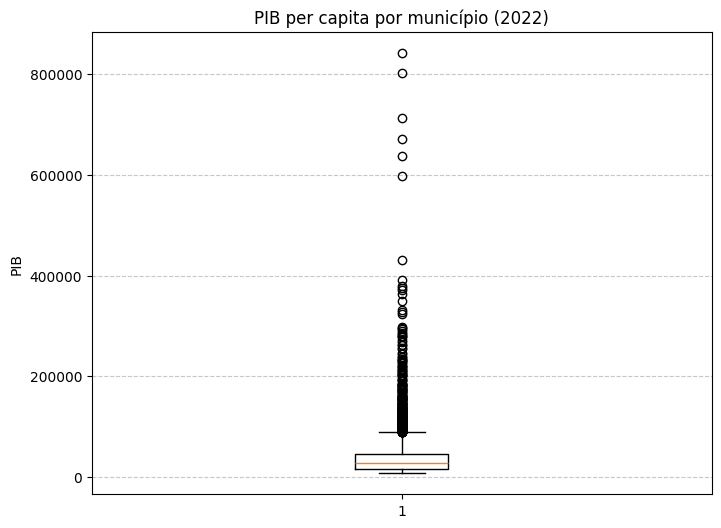

In [ ]:
# Visualização do boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(gdf_mun_pib['pib'].dropna())
plt.title('PIB per capita por município (2022)')
plt.ylabel('PIB')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Limiares para o mapa
q1 = gdf_mun_pib['pib'].quantile(0.25)
q2 = gdf_mun_pib['pib'].quantile(0.50) # Mediana
q3 = gdf_mun_pib['pib'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

min_pib = gdf_mun_pib['pib'].min()
max_pib = gdf_mun_pib['pib'].max()

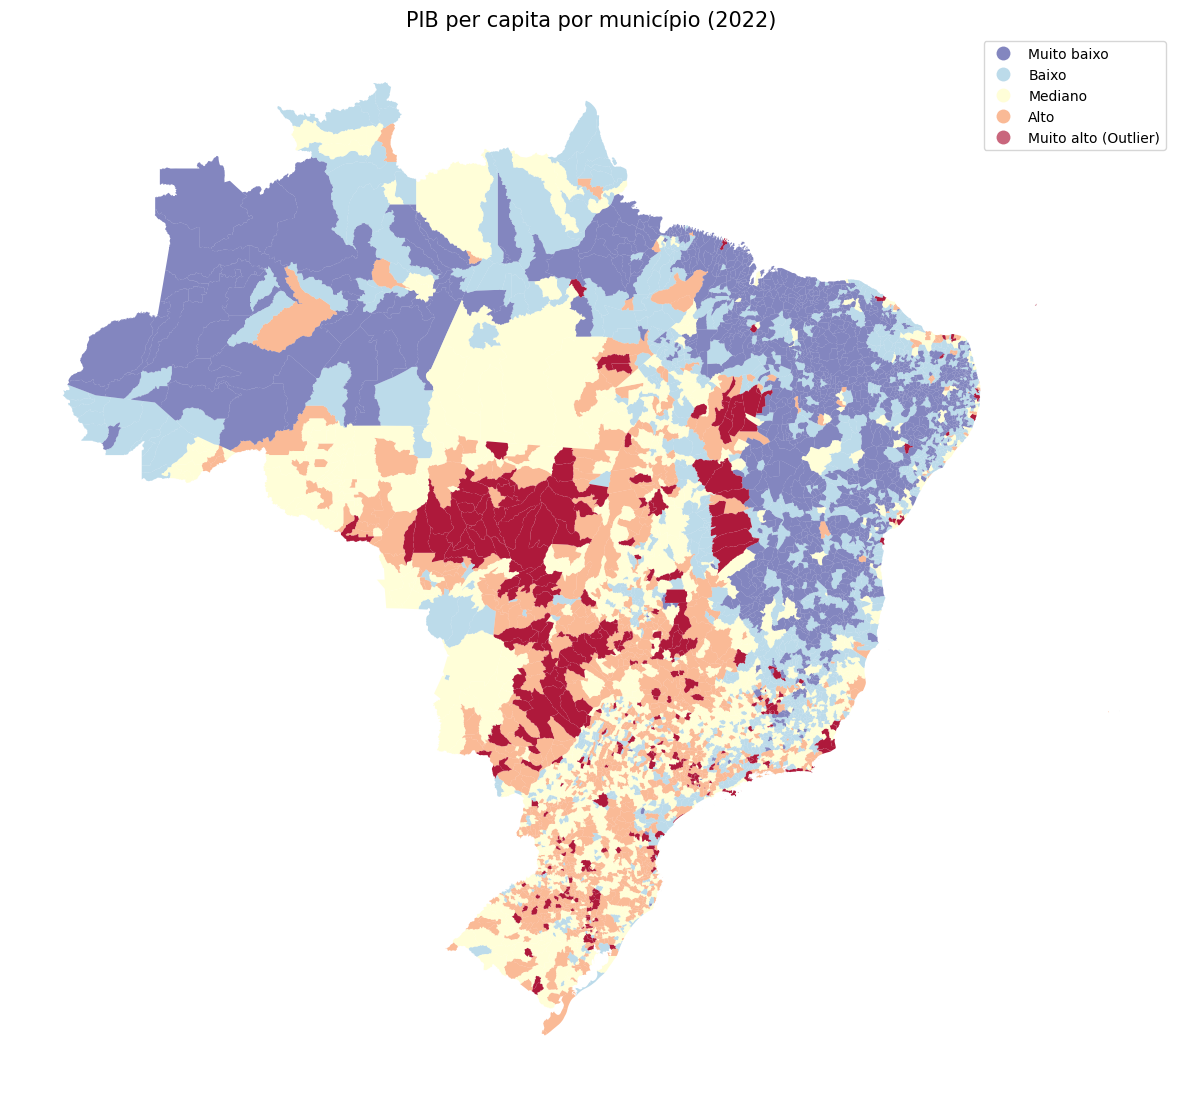

In [ ]:
# Visualizando boxplot no mapa
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# outliers (transparência alta)
gdf_mun_pib[
    gdf_mun_pib['pib_category'] != 'Muito alto (Outlier)'
].plot(
    column='pib_category',
    cmap='RdYlBu_r',
    linewidth=0.0,
    ax=ax,
    legend=True,
    categorical=True,
    alpha=0.6
)

# OUTLIERS (destaque)
gdf_mun_pib[
    gdf_mun_pib['pib_category'] == 'Muito alto (Outlier)'
].plot(
    column='pib_category',
    cmap='RdYlBu_r',
    linewidth=0.0,
    edgecolor='white',
    ax=ax,
    alpha=0.9
)

ax.set_title('PIB per capita por município (2022)', fontsize=15)
ax.set_axis_off()
plt.show()
